# Comprehensive Case Study – Recipe Review Ratings Prediction
 
#### Bruno de Arantes Leite Sassi

# 1 Data Cleaning:
Prepare the dataset for analysis by resolving common data quality issues.
-	Identify and handle missing values. In this dataset, the value '2' is sometimes used as a placeholder for missing data.
-	Remove or review duplicates and inconsistencies
-	Ensure correct data types
-	Normalize inconsistent categorical values


In [1]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.compose import make_column_selector as selector
from sklearn.impute import SimpleImputer


df = pd.read_csv('recipe_reviews.csv')
df.head()

,Unnamed: 0,recipe_number,recipe_code,likes_score,dislike_index,response_level,user_index,ranking_value,vote_ratio,score_log,...,user_id,user_name,user_score,created_at,responses,likes,dislikes,ranking_score,text,stars
0,0,1,14299,0.104335,-0.087082,-0.001580,1.172032,539.698328,0.000000,0.693147,...,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,527,"I tweaked it a little, removed onions because ...",5
1,1,1,14299,6.970958,-0.094496,-0.002169,50.629458,720.511995,0.875000,3.931826,...,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,724,Bush used to have a white chili bean and it ma...,5
2,2,1,14299,3.136047,-0.047194,0.014539,10.742998,717.194563,0.750000,2.397895,...,u_s0LwgpZ8Jsqq,Barbara566,10,1664404557,0,3,0,710,I have a very complicated white chicken chili ...,5
3,3,1,14299,2.319913,-0.107932,2.012194,0.865812,585.875342,0.666667,0.693147,...,u_fqrybAdYjgjG,jeansch123,1,1661787808,2,2,0,581,"In your introduction, you mentioned cream chee...",0
4,4,1,14299,6.950816,0.142649,1.009770,8.985971,815.148751,0.875000,2.397895,...,u_XXWKwVhKZD69,camper77,10,1664913823,1,7,0,820,Wonderful! I made this for a &#34;Chili/Stew&#...,0


In [3]:
# Display basic information about the DataFrame
print(df.info())

# Check for missing values in each column
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18182 entries, 0 to 18181
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      18182 non-null  int64  
 1   recipe_number   18182 non-null  int64  
 2   recipe_code     18182 non-null  int64  
 3   likes_score     18182 non-null  float64
 4   dislike_index   18182 non-null  float64
 5   response_level  18182 non-null  float64
 6   user_index      18182 non-null  float64
 7   ranking_value   18182 non-null  float64
 8   vote_ratio      18182 non-null  float64
 9   score_log       18182 non-null  float64
 10  region          18182 non-null  object 
 11  device_type     18182 non-null  object 
 12  recipe_name     18182 non-null  object 
 13  comment_id      18182 non-null  object 
 14  user_id         18182 non-null  object 
 15  user_name       18182 non-null  object 
 16  user_score      18182 non-null  int64  
 17  created_at      18182 non-null 

In [4]:
# convert created_at to date (UTC) - considering Unix seconds :
df["created_at"] = pd.to_datetime(df["created_at"], unit="s", utc=True)

# check the range of resulting dates
print(df["created_at"].min(), df["created_at"].max())


2021-02-11 09:22:16+00:00 2022-10-14 14:00:35+00:00


In [5]:
# check '2' values in each column based on data type
print(df.select_dtypes(include="int64").eq(2).sum())
print(df.select_dtypes(include="float64").eq(2.0).sum())
print(df.select_dtypes(include="object").eq("2").sum())

# check unique values in each non numeric column
for i in df.select_dtypes(include=['object']).columns:
    print(f"\n Unique values in '{i}':")
    print(df[i].value_counts())

Unnamed: 0       100
recipe_number    509
recipe_code        0
user_score         0
responses         24
likes            624
dislikes         388
ranking_score      0
stars            232
dtype: int64
likes_score       0
dislike_index     0
response_level    0
user_index        0
ranking_value     0
vote_ratio        0
score_log         0
dtype: int64
region         0
device_type    0
recipe_name    0
comment_id     0
user_id        0
user_name      0
text           0
dtype: int64

 Unique values in 'region':
region
West     4603
North    4569
South    4530
East     4480
Name: count, dtype: int64

 Unique values in 'device_type':
device_type
Desktop    6093
Mobile     6065
Tablet     6024
Name: count, dtype: int64

 Unique values in 'recipe_name':
recipe_name
Cheeseburger Soup               725
Creamy White Chili              654
Best Ever Banana Bread          509
Enchilada Casser-Ole!           421
Basic Homemade Bread            397
                               ... 
Peanut Butter

Looking into the data, the potential placeholders for missing data could be:

Unnamed: 0 (100)
recipe_number (509)

And likely real data (true value = 2):

responses (24)
likes (624)
dislikes (388)
stars (232)

In [6]:
# with that, we look int the potential placeholders for missing data
print(df.loc[df['Unnamed: 0'] == 2].head())
df.loc[df['recipe_number'] == 2].head()

      Unnamed: 0  recipe_number  recipe_code  likes_score  dislike_index  \
2              2              1        14299     3.136047      -0.047194   
656            2              2         3309     8.002926      -0.170622   
1165           2              3         2832     4.512470      -0.183833   
1890           2              4        17826    13.114747       2.014801   
2228           2              5        42386     5.607933       0.168601   

      response_level  user_index  ranking_value  vote_ratio  score_log  ...  \
2           0.014539   10.742998     717.194563    0.750000   2.397895  ...   
656         0.002936    9.984581     804.508907    0.888889   2.397895  ...   
1165       -0.003401    0.701496     752.847500    0.800000   0.693147  ...   
1890        0.002302    0.640166     824.147276    0.812500   0.693147  ...   
2228       -0.004867    0.085296     380.059627    0.857143   0.693147  ...   

                            user_id     user_name user_score  \
2   

,Unnamed: 0,recipe_number,recipe_code,likes_score,dislike_index,response_level,user_index,ranking_value,vote_ratio,score_log,...,user_id,user_name,user_score,created_at,responses,likes,dislikes,ranking_score,text,stars
654,0,2,3309,0.540535,-0.325465,0.009293,1.303253,511.855387,0.000000,0.693147,...,u_fjZn9UjnYY9Y,ritajandj,1,2022-10-07 18:15:53+00:00,0,0,0,510,This is the best recipe for banana bread I&#39...,5
655,1,2,3309,0.012439,0.263778,-0.010166,49.017775,479.412763,0.000000,3.931826,...,u_qW2rjMVr5SYl,mrscessna,50,2022-09-15 21:56:06+00:00,0,0,0,488,sweet and moist! I will be making this again,4
656,2,2,3309,8.002926,-0.170622,0.002936,9.984581,804.508907,0.888889,2.397895,...,u_iWjGINSSoqyU,danielleylee,10,2022-07-27 10:36:43+00:00,0,8,0,825,I made this bread with one minor twist. I live...,5
657,3,2,3309,5.994933,0.834753,-0.001685,70.092742,756.730532,0.750000,4.262680,...,u_j6XdnbRT1vtZ,Joan9859,70,2022-07-20 02:41:19+00:00,0,6,1,750,"In place of the 1/2 cup of oil, I used another...",5
658,4,2,3309,4.041608,-0.057006,0.010549,19.668864,755.964588,0.800000,3.044522,...,u_f2qPJ3428ktq,dcscake_OH,20,2022-05-31 14:07:11+00:00,0,4,0,759,"Made this for my book club, but used sour crea...",5


In [7]:
# check if all rows in recipe_code are the same when recipe_number == 2
df.loc[df['recipe_number'] == 2, ['recipe_code', 'recipe_number']].nunique()

recipe_code      1
recipe_number    1
dtype: int64

Whenever recipe_number == 2, the recipe_code is consistently 3309.

That consistency suggests those records are real recipes that genuinely have recipe_number = 2.

So in this case, 2 is valid data, not a missing placeholder. From this is worth checking if the two columns are redundant.

For the Unnamed: 0 column, on the other hand, it does look like number 2 entries are potential placeholders for missing data, but the column itself doesnt seem to add any value , so it better to drop the whole column.

In [8]:
# drop Unnamed: 0 since it is just an index
df = df.drop(columns=["Unnamed: 0"])

# Check column redundancy between recipe_number and recipe_code
# Check if each recipe_number maps to a single recipe_code
num_to_code = df.groupby("recipe_number")["recipe_code"].nunique()

# Check if each recipe_code maps to a single recipe_number
code_to_num = df.groupby("recipe_code")["recipe_number"].nunique()

print("recipe_number → unique recipe_code counts:")
print(num_to_code.value_counts())  # distribution of how many codes per number

print("\nrecipe_code → unique recipe_number counts:")
print(code_to_num.value_counts())

recipe_number → unique recipe_code counts:
recipe_code
1    100
Name: count, dtype: int64

recipe_code → unique recipe_number counts:
recipe_number
1    100
Name: count, dtype: int64


In [9]:
# drop recipe_number since it is redundant
df = df.drop(columns=["recipe_number"])
df.head(3)

,recipe_code,likes_score,dislike_index,response_level,user_index,ranking_value,vote_ratio,score_log,region,device_type,...,user_id,user_name,user_score,created_at,responses,likes,dislikes,ranking_score,text,stars
0,14299,0.104335,-0.087082,-0.001580,1.172032,539.698328,0.000,0.693147,North,Tablet,...,u_9iFLIhMa8QaG,Jeri326,1,2022-10-13 00:11:29+00:00,0,0,0,527,"I tweaked it a little, removed onions because ...",5
1,14299,6.970958,-0.094496,-0.002169,50.629458,720.511995,0.875,3.931826,West,Mobile,...,u_Lu6p25tmE77j,Mark467,50,2022-10-09 01:08:07+00:00,0,7,0,724,Bush used to have a white chili bean and it ma...,5
2,14299,3.136047,-0.047194,0.014539,10.742998,717.194563,0.750,2.397895,North,Desktop,...,u_s0LwgpZ8Jsqq,Barbara566,10,2022-09-28 22:35:57+00:00,0,3,0,710,I have a very complicated white chicken chili ...,5


Upon a closer look, many columns act as IDs or indexes that cannot be generalized, including 'recipe_code'. Since the goal is to create a prediction model, those will be dropped to avoid unecessary or useless work.

In [10]:
# Drop: IDs (recipe_code, user_index, user_id, created_at, comment_id, recipe_name, user_name).
df = df.drop(columns=["recipe_code", "user_index", "user_id", "created_at", "comment_id", "user_name"])
# converting created_at to date showed a small window of time, so it probably won't be useful for prediction too
df.head(3)

,likes_score,dislike_index,response_level,ranking_value,vote_ratio,score_log,region,device_type,recipe_name,user_score,responses,likes,dislikes,ranking_score,text,stars
0,0.104335,-0.087082,-0.001580,539.698328,0.000,0.693147,North,Tablet,Creamy White Chili,1,0,0,0,527,"I tweaked it a little, removed onions because ...",5
1,6.970958,-0.094496,-0.002169,720.511995,0.875,3.931826,West,Mobile,Creamy White Chili,50,0,7,0,724,Bush used to have a white chili bean and it ma...,5
2,3.136047,-0.047194,0.014539,717.194563,0.750,2.397895,North,Desktop,Creamy White Chili,10,0,3,0,710,I have a very complicated white chicken chili ...,5


# 2 Exploratory Data Analysis (EDA):
Explore and understand the structure, trends, and relationships in the data.
- 	Analyze data and generate summary statistics
- 	Visualize distributions and correlations
- 	Explore how different features relate to star ratings


In [11]:
#check basic statistics for numerical columns
df.describe()

,likes_score,dislike_index,response_level,ranking_value,vote_ratio,score_log,user_score,responses,likes,dislikes,ranking_score,stars
count,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000
mean,1.090385,0.547333,0.014671,153.207674,0.129895,0.812869,2.159608,0.014630,1.089264,0.549335,153.162138,4.288802
std,4.204683,3.474311,0.138211,141.249272,0.256619,0.521095,10.014666,0.137974,4.201004,3.470124,141.075316,1.544786
min,-0.805890,-0.774810,-0.029633,-8.726157,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.096429,-0.099743,-0.004531,96.796338,0.000000,0.693147,1.000000,0.000000,0.000000,0.000000,100.000000,5.000000
50%,0.078797,0.029246,0.000193,102.660964,0.000000,0.693147,1.000000,0.000000,0.000000,0.000000,100.000000,5.000000
75%,0.383414,0.188243,0.004917,113.329761,0.000000,0.693147,1.000000,0.000000,0.000000,0.000000,100.000000,5.000000
max,105.766878,126.052512,3.004809,944.834309,0.976744,6.255750,520.000000,3.000000,106.000000,126.000000,946.000000,5.000000


In [12]:
# Bag-of-words / TF-IDF on recipe_name
vectorizer = TfidfVectorizer(
    max_features=500,  # keep top words only
    stop_words="english",
    ngram_range=(1,2)  # unigrams + bigrams
)
X_text = vectorizer.fit_transform(df["recipe_name"].fillna(""))


In [13]:
# Keyword analysis
# simple token split
words = df["recipe_name"].str.lower().str.split()
word_counts = Counter([w for row in words.dropna() for w in row])
top_words = [w for w, c in word_counts.most_common(50)]

# see mean stars per top word
out = {}
for w in top_words:
    mask = df["recipe_name"].str.lower().str.contains(rf"\b{w}\b", na=False)
    out[w] = df.loc[mask, "stars"].mean()
pd.Series(out).sort_values()


lime            3.227564
pineapple       3.367164
fluffy          3.523161
pie             3.809524
homemade        3.937853
meat            4.063158
basic           4.063228
apple           4.068340
cake            4.076923
enchilada       4.099762
baked           4.154982
butter          4.188285
peanut          4.188285
and             4.228650
potatoes        4.252336
salad           4.286420
chocolate       4.292616
chowder         4.294461
huli            4.317073
with            4.333333
lasagna         4.338425
bars            4.348993
chili           4.354057
bread           4.358941
creamy          4.369963
flavorful       4.379699
cheese          4.380090
white           4.383736
chicken         4.385791
macaroni        4.394541
pudding         4.395735
pumpkin         4.400000
favorite        4.432282
coleslaw        4.450746
cream           4.458150
casserole       4.460946
frosting        4.484663
soup            4.511111
potpie          4.513924
cheeseburger    4.515152


In [14]:
# --- basic tokenization (keep words & simple bigrams if you want) ---
def tokenize(s):
    if pd.isna(s): return []
    # lowercase, keep letters, numbers, apostrophes; split on non-word boundaries
    tokens = re.findall(r"[a-zA-Z0-9']+", s.lower())
    return tokens

# tokens per row
tokens_series = df["recipe_name"].apply(tokenize)

# frequency table (unigrams)
freq = Counter([t for row in tokens_series for t in row])

# pick a vocabulary to analyze (e.g., top 200 frequent, drop 1-char tokens)
vocab = [w for w, c in freq.most_common(200) if len(w) > 1]


In [15]:
# Create a column with lenght of text
df['text_word_count'] = df['text'].fillna('').apply(lambda x: len(x.split()))
df['text_char_count'] = df['text'].fillna('').apply(lambda x: len(x.replace(' ', '')))
df[['text_word_count', 'text_char_count']].describe()

,text_word_count,text_char_count
count,18182.000000,18182.000000
mean,37.810527,165.835387
std,32.093552,139.489083
min,0.000000,0.000000
25%,16.000000,74.000000
50%,30.000000,131.000000
75%,49.000000,216.000000
max,499.000000,2215.000000


14 ['likes_score', 'dislike_index', 'response_level', 'ranking_value', 'vote_ratio', 'score_log', 'user_score', 'responses', 'likes', 'dislikes', 'ranking_score', 'stars', 'text_word_count', 'text_char_count']


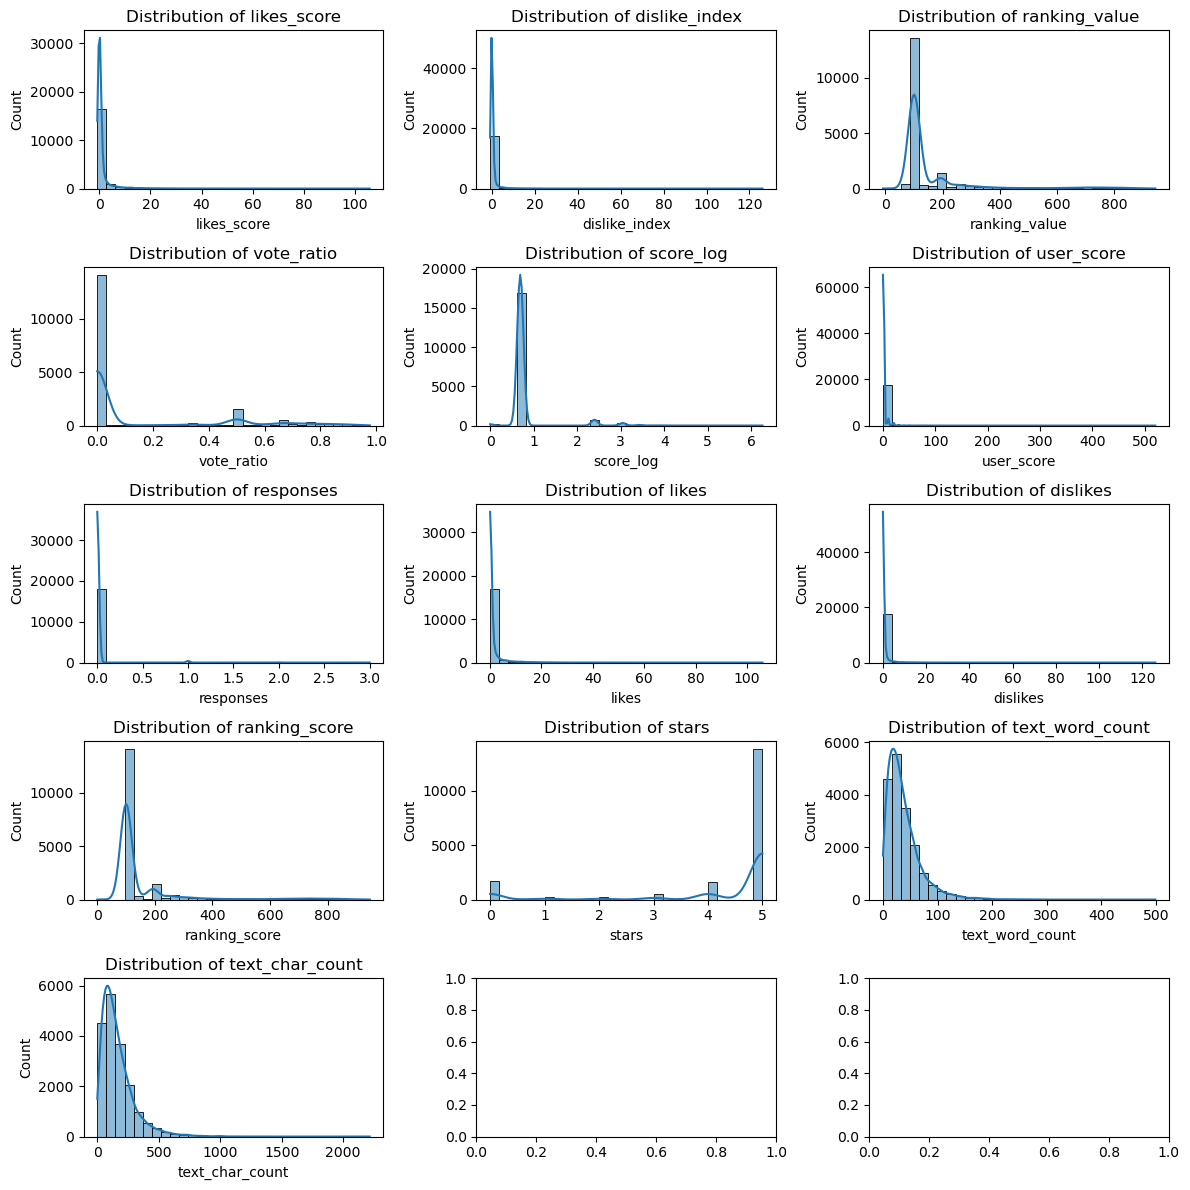

In [16]:
# Select numerical columns for visualization
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(len(numerical_columns), numerical_columns)

# remove id-like and categorical-like features
numerical_columns.remove('response_level') 

# Create a grid of subplots for the selected numerical features
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(12, 12))  # Adjust grid size
axes = axes.flatten()

# Plot histograms for the selected numerical features
for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Adjust layout
plt.tight_layout()
plt.show()

* likes_score — Mass near 0 with a long right tail → most items have low scores; a few get very large.

* dislike_index — Same pattern as likes_score: heavy near 0, long tail.

* ranking_value — Unimodal cluster with a noticeable right tail; plausible continuous score; check for outliers.

* vote_ratio — Values packed near 0 with distinct clumps (likely from small integer counts, e.g., 0, 1/2, 2/3, etc.). Ratio is in [0,1]; heavy zero-inflation.

* score_log — Peak at low values and a long tail up to ~6 → a typical log-transformed popularity metric with a few very large items.

* user_score — Zero-inflated with a long tail to very large values; strong popularity/engagement skew.

* responses — Small integer support (0–3) with a dominant 0 → most items have no responses; classic zero-inflation.

* likes — Many zeros and a long tail (further than dislikes) → few items accumulate lots of likes.

* dislikes — Same shape as likes but lower overall and shorter tail → dislikes are rarer than likes.

* ranking_score — Concentrated at low values with a right tail; consistent with an aggregate/derived score.

* stars — Discrete at 0–5 with tall bars at 0 and 5 → bimodal. The 0s may mean “no rating / unrated” rather than a true star value; worth confirming business logic.

* text_word_count - More concentrated in low values, right skewed and with long tail

* text_chart_count - More concentrated in low values, right skewed and with long tail

What stands out / action items

* Zero-inflation + long tails: likes, dislikes, responses, user_score, likes_score, dislike_index → consider log1p transforms, robust scalers, or zero-inflated models; be careful with outliers.

* Stars: The spike at 0 suggests a special meaning (unrated). Decide whether stars==0 should be treated as missing.

In [17]:
# checking star == 0 entries to decide is 0 is a valid rate or absense of it (missing)
df.loc[df['stars'] == 0]

,likes_score,dislike_index,response_level,ranking_value,vote_ratio,score_log,region,device_type,recipe_name,user_score,responses,likes,dislikes,ranking_score,text,stars,text_word_count,text_char_count
3,2.319913,-0.107932,2.012194,585.875342,0.666667,0.693147,South,Tablet,Creamy White Chili,1,2,2,0,581,"In your introduction, you mentioned cream chee...",0,15,79
4,6.950816,0.142649,1.009770,815.148751,0.875000,2.397895,North,Desktop,Creamy White Chili,10,1,7,0,820,Wonderful! I made this for a &#34;Chili/Stew&#...,0,42,196
7,28.161200,2.117031,-0.000154,887.212987,0.903226,0.693147,East,Desktop,Creamy White Chili,1,0,28,2,891,This is delicious and I make it often. One suc...,0,119,467
23,4.700731,28.761533,1.003869,527.679876,0.142857,0.693147,West,Desktop,Creamy White Chili,1,1,5,29,530,This is just White Chicken Chili with I first ...,0,38,181
29,2.938730,0.194337,-0.002894,297.648336,0.750000,0.693147,East,Tablet,Creamy White Chili,1,0,3,0,297,I would make this soup again. It was a hit. ...,0,29,107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18073,12.831117,5.086834,0.003755,760.501163,0.684211,0.693147,East,Mobile,Mamaw Emily’s Strawberry Cake,1,0,13,5,759,I just made this for the first time. I haven&#...,0,67,305
18075,3.950396,16.042441,2.001651,133.113423,0.190476,0.000000,West,Tablet,Mamaw Emily’s Strawberry Cake,0,2,4,16,136,"Waste of time and ingredients, cake ran over n...",0,22,92
18103,0.871160,0.086018,-0.007314,192.370658,0.500000,0.693147,East,Tablet,Mamaw Emily’s Strawberry Cake,1,0,1,0,193,Can this cake be frozen?,0,5,20
18126,-0.077969,-0.165363,-0.000501,102.654874,0.000000,0.693147,North,Desktop,Mamaw Emily’s Strawberry Cake,1,0,0,0,100,Love it making another one keep up the good w...,0,12,47


Sample Results indicate that 0 stars is more likely to be the absense of rating, rather than a zero score, since a good proportion of texts speak highly of the recipe.

In [18]:
# percentage of 0 stars entries
print(len(df.loc[df['stars'] == 0])/len(df)*100 )
print( "Total entries x 0 stars entries: ", len(df), " x ", len(df.loc[df['stars'] == 0]) )

9.327906720932791
Total entries x 0 stars entries:  18182  x  1696


The percentage of missing ratings in stars is relevant (9,33%), however stars are the core of the current research and even without this entries the dataset has a good size, so I'll drop those rows.

In [19]:
# Drop rows with 0 stars since they are likely missing ratings
df = df[df['stars'] != 0]
# check the new size of the dataset
df.shape

(16486, 18)

Check relationship between numerical features and 'stars'


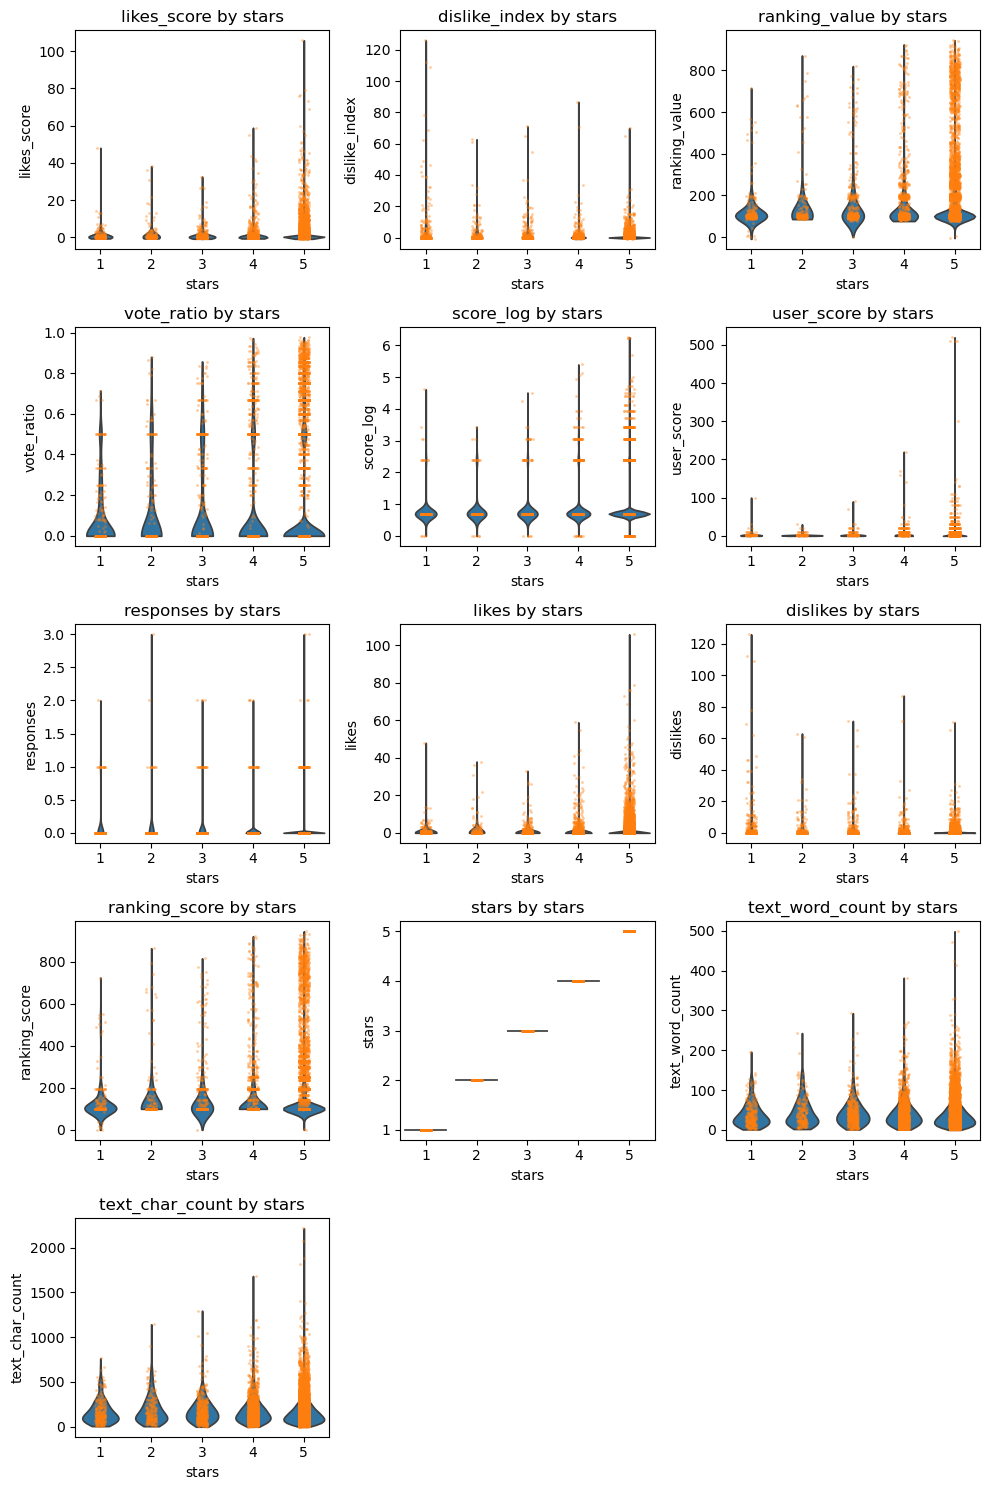

In [20]:
# Check relationship between numerical features and 'stars'
n = len(numerical_columns)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 3*nrows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    ax = axes[i]
    sns.violinplot(x="stars", y=col, data=df, inner=None, cut=0, ax=ax)
    sns.stripplot(x="stars", y=col, data=df, ax=ax, size=2, alpha=0.4, jitter=True)
    ax.set_title(f"{col} by stars")
    # optional for heavy-tailed metrics:
    # ax.set_yscale("symlog")

for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Focusing on shape, trend or any highlight.

* **likes\_score by stars** — Clear upward trend; dispersion explodes at 5. Heavy zero-inflation at low stars.
* **dislike\_index by stars** — Mostly near zero across all stars; slight rise and longer tail at 5 (likely exposure effect—popular items get more of everything, including dislikes).
* **ranking\_value by stars** — Increases with stars; much fatter tail at 5 → aligns with rating.
* **vote\_ratio by stars** — Nicely monotonic upward separation across star levels; looks like a strong predictor.
* **score\_log by stars** — Steady rise with stars; compact at low stars, wider at 4–5 → strong association.
* **user\_score by stars** — Same story as likes\_score: higher stars → higher center and variance; heavy right tail at 5.
* **responses by stars** — Small integer support; mostly 0’s at every star, slight uptick with higher stars but weak separation.
* **likes by stars** — Strongly increasing with stars; zero-inflated overall, very long tail at 5.
* **dislikes by stars** — Low counts everywhere; modest increase and longer tail at 5 (again likely exposure, not sentiment).
* **ranking\_score by stars** — Strong positive relationship; extreme spread for 5-star items.
* stars by stars — created automatically → ignore
* **text_word_coutn** - The distribution widens as stars increase, with 4–5 star reviews tending to have higher word counts.
* **text_char_count** - The distribution widens as stars increase, with 4–5 star reviews tending to have higher charactercounts.

What stands out

* **Monotonic relationships:** vote\_ratio, score\_log, ranking\_value/score, likes/user\_score all rise with stars → likely the most informative features.
* **Exposure effect:** dislikes and dislike\_index also rise at high stars; not contradictory—popular items attract more interactions of all kinds.
* **Zero-inflation & heavy tails:** likes, user\_score, responses show many zeros and a few very large values → consider `log1p`/robust scaling and outlier-aware summaries.
* **Class imbalance risk:** low-star categories look sparser than 5-star.
* **text count** - users who leave bigger reviews tend to give higher stars 


In [21]:
# make stars an ordered categorical (handy for plots / stats)
df["stars_cat"] = pd.Categorical(df["stars"], categories=[1,2,3,4,5], ordered=True)

# pick numeric columns (drop the target)
num_cols = df.select_dtypes(include="number").columns.drop("stars")

# drop obvious ID-like columns automatically
uniq_ratio = df[num_cols].nunique() / len(df)
id_like = uniq_ratio[uniq_ratio > 0.9].index  
num_cols = [c for c in num_cols if c not in id_like]
num_cols
print (num_cols)
print (id_like)

['vote_ratio', 'score_log', 'user_score', 'responses', 'likes', 'dislikes', 'ranking_score', 'text_word_count', 'text_char_count']
Index(['likes_score', 'dislike_index', 'response_level', 'ranking_value'], dtype='object')


In [22]:
# Check Class balance
counts = df["stars"].value_counts().sort_index()
props  = (counts / counts.sum()).round(3)
display(pd.DataFrame({"count": counts, "proportion": props}))


,count,proportion
stars,,
1,280,0.017
2,232,0.014
3,490,0.030
4,1655,0.100
5,13829,0.839


In [23]:
# Monotonic association (Spearman’s ρ)
from scipy.stats import spearmanr

rows = []
for col in num_cols:
    s = df[col]
    ok = s.notna() & df["stars"].notna()
    rho, p = spearmanr(s[ok], df.loc[ok, "stars"])
    rows.append((col, rho, p))

spearman_df = (pd.DataFrame(rows, columns=["feature","spearman_rho","p"])
                 .assign(abs_rho=lambda x: x["spearman_rho"].abs())
                 .sort_values("abs_rho", ascending=False))
spearman_df.head(10)


,feature,spearman_rho,p,abs_rho
5,dislikes,-0.182415,2.497653e-123,0.182415
3,responses,-0.104867,1.544463e-41,0.104867
7,text_word_count,-0.050380,9.655416e-11,0.050380
8,text_char_count,-0.045031,7.277041e-09,0.045031
4,likes,-0.032577,2.869916e-05,0.032577
6,ranking_score,-0.018692,1.639298e-02,0.018692
0,vote_ratio,-0.016629,3.274892e-02,0.016629
1,score_log,-0.008596,2.697292e-01,0.008596
2,user_score,-0.008596,2.697292e-01,0.008596


In [24]:
# Nonparametric group differences (Kruskal–Wallis) + effect size
# “do distributions differ across 1–5★ ?

from scipy.stats import kruskal

kw_rows = []
groups = [g for _, g in df.groupby("stars")]
k = len(groups)
N = len(df)

for col in num_cols:
    arrays = [g[col].dropna().values for g in groups]
    if sum(len(a) > 0 for a in arrays) < k:  # need data in all groups
        continue
    H, p = kruskal(*arrays)
    # Epsilon-squared (nonparametric effect size)
    eps2 = (H - (k - 1)) / (N - 1)
    kw_rows.append((col, H, p, eps2))

kw_df = (pd.DataFrame(kw_rows, columns=["feature","H","p","epsilon_sq"])
           .sort_values("epsilon_sq", ascending=False))
kw_df.head(10)


,feature,H,p,epsilon_sq
5,dislikes,935.744076,2.997851e-201,0.056521
3,responses,255.839500,3.593172e-54,0.015277
7,text_word_count,47.236900,1.361126e-09,0.002623
8,text_char_count,38.143923,1.046507e-07,0.002071
4,likes,37.425567,1.471937e-07,0.002028
6,ranking_score,14.869258,4.980210e-03,0.000659
0,vote_ratio,13.852817,7.779925e-03,0.000598
1,score_log,7.885897,9.584851e-02,0.000236
2,user_score,7.885897,9.584851e-02,0.000236


In [25]:
# Multiple testing control (BH–FDR)
# Benjamini-Hochberg procedure

def bh_fdr(pvals, alpha=0.05):
    p = np.asarray(pvals)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order]
    thresh = alpha * (np.arange(1, m+1) / m)
    passed = ranked <= thresh
    cutoff = np.max(np.where(passed)[0]) if passed.any() else -1
    crit = ranked[cutoff] if cutoff >= 0 else 0
    return (p <= crit), crit

kw_df = kw_df.copy()
kw_df["reject_fdr"], fdr_cut = bh_fdr(kw_df["p"].values, alpha=0.05)
kw_df.head(10)


,feature,H,p,epsilon_sq,reject_fdr
5,dislikes,935.744076,2.997851e-201,0.056521,True
3,responses,255.839500,3.593172e-54,0.015277,True
7,text_word_count,47.236900,1.361126e-09,0.002623,True
8,text_char_count,38.143923,1.046507e-07,0.002071,True
4,likes,37.425567,1.471937e-07,0.002028,True
6,ranking_score,14.869258,4.980210e-03,0.000659,True
0,vote_ratio,13.852817,7.779925e-03,0.000598,True
1,score_log,7.885897,9.584851e-02,0.000236,False
2,user_score,7.885897,9.584851e-02,0.000236,False


In [26]:
# re-run Spearman on log1p for heavy-tailed metrics
heavy = [c for c in num_cols if (df[c] >= 0).all() and (df[c] == 0).mean() > 0.3]

rows = []
for col in heavy:
    s = np.log1p(df[col])
    ok = s.notna()
    rho, p = spearmanr(s[ok], df.loc[ok, "stars"])
    rows.append((col, rho, p))

spearman_log_df = (pd.DataFrame(rows, columns=["feature","spearman_rho_log1p","p_log1p"])
                     .assign(abs_rho_log1p=lambda x: x["spearman_rho_log1p"].abs())
                     .sort_values("abs_rho_log1p", ascending=False))
spearman_log_df.head(10)


,feature,spearman_rho_log1p,p_log1p,abs_rho_log1p
3,dislikes,-0.182415,2.497653e-123,0.182415
1,responses,-0.104867,1.544463e-41,0.104867
2,likes,-0.032577,2.869916e-05,0.032577
0,vote_ratio,-0.016629,3.274892e-02,0.016629


Why p-values look tiny but correlations are tiny

* huge sample size + many ties/zeros → very small p-values even when the effect size is trivial.

* Focus on effect sizes: only dislikes is “moderate-ish” (ε² ≈ 0.057). Everything else is small to negligible.

About the log1p re-run

* Spearman uses ranks, so any monotonic transform (like log1p) doesn’t change ranks → the correlations stay the same. That’s why “log1p” table didn’t move.

What stands out / implications

* Dislikes decreases with higher stars (as expected) and is the clearest separator.

* Responses, likes, ranking_score, vote_ratio show visually sensible trends, but on the whole dataset their effects are weak because of zero-inflation and overlap.

* For relationships to pop out more, control for exposure will be needed (items with more visibility get more of everything).

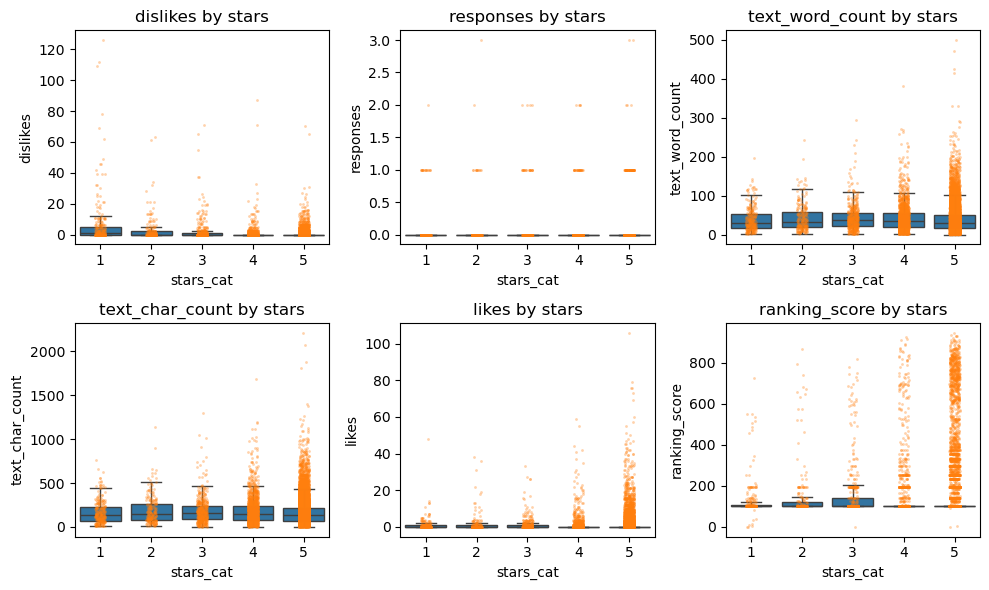

In [27]:
# Visualize top features
# pick top features by Spearman’s ρ
top = spearman_df.head(6)["feature"].tolist()

n = len(top); ncols = 3; nrows = (n + ncols - 1)//ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 3*nrows))
axes = axes.flatten()

for ax, col in zip(axes, top):
    sns.boxplot(data=df, x="stars_cat", y=col, ax=ax, showfliers=False)
    sns.stripplot(data=df, x="stars_cat", y=col, ax=ax, size=2, alpha=0.35, jitter=True)
    ax.set_title(f"{col} by stars")
for j in range(len(top), len(axes)): fig.delaxes(axes[j])
plt.tight_layout(); plt.show()


Panel-by-panel (x = stars 1–5)

* **dislikes by stars** – Medians drop as stars rise; a few huge outliers at low stars.
⇒ Matches Spearman ρ = −0.18 (strongest signal here) and the largest KW effect (ε² ≈ 0.057).

* **responses by stars** – Almost all zeros at every star, tiny lift at low stars.
⇒ ρ = −0.10, KW significant but small effect (ε² ≈ 0.015).

* **likes by stars** – Most rows have 0 likes; big tails appear at 4–5★ but medians stay ~0.
⇒ Visual “more big values at 5★” but overall ρ ≈ −0.03 (essentially none), KW significant yet tiny effect (ε² ≈ 0.002) due to large N.

* **ranking_score by stars** – Tends upward, especially at 5★, but still heavy overlap.
⇒ ρ ≈ −0.019 (negligible), KW significant with very small effect (ε² ≈ 0.0007).

* **vote_ratio by stars** – Clear upward shift across stars (lower stars near 0, 5★ near 0.8–0.9).
⇒ Spearman shows ρ ≈ −0.017 (basically zero; the sign is dominated by ties/zeros), KW significant but again tiny effect (ε² ≈ 0.0006).

* **score_log by stars** – Step up at higher stars but lots of ties at 0/low values; broad overlap.
⇒ ρ ≈ −0.009 and KW not significant after FDR (tiny effect).


# 3 Visualization:
Use effective visuals to support your analysis.
- 	Include charts such as bar plots, feature importance, and heatmaps
- 	Make all visualizations interpretable and relevant
- 	Label axes, legends, and titles clearly


In [28]:
cat_cols = df.select_dtypes(include="object").columns
df[cat_cols].nunique().sort_values()


device_type        3
region             4
recipe_name      100
text           16096
dtype: int64

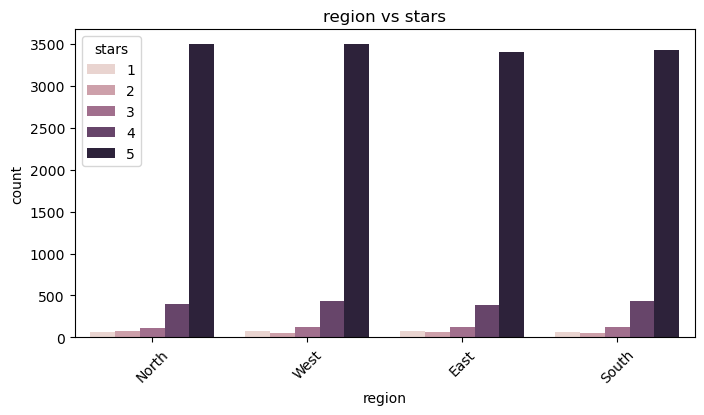

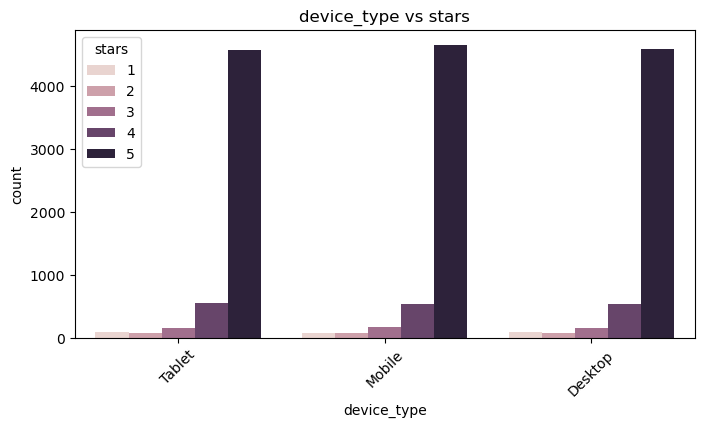

In [29]:
# Class balance by category
cat_cols = cat_cols.tolist()
cat_cols.remove('recipe_name')  # too many levels
cat_cols.remove('text')         # too many levels

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue="stars")
    plt.title(f"{col} vs stars")
    plt.xticks(rotation=45)
    plt.show()


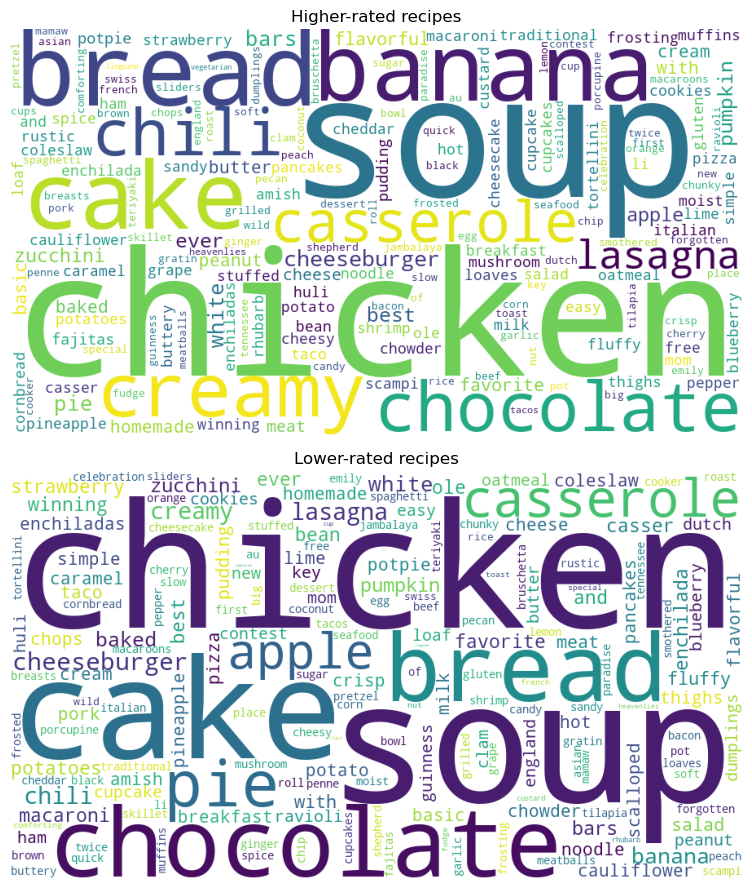

In [30]:
# choose a threshold; you can change to your scale (e.g., 4.5)
hi_mask = df["stars"] >= df["stars"].median()
lo_mask = ~hi_mask

hi_tokens = df.loc[hi_mask, "recipe_name"].apply(tokenize)
lo_tokens = df.loc[lo_mask, "recipe_name"].apply(tokenize)

hi_freq = Counter([t for row in hi_tokens for t in row])
lo_freq = Counter([t for row in lo_tokens for t in row])

hi_wc = WordCloud(width=900, height=500, background_color="white").generate_from_frequencies(
    {w: hi_freq[w] for w in vocab if hi_freq[w] > 0}
)
lo_wc = WordCloud(width=900, height=500, background_color="white").generate_from_frequencies(
    {w: lo_freq[w] for w in vocab if lo_freq[w] > 0}
)

plt.figure(figsize=(14,9))
plt.subplot(2,1,1)
plt.imshow(hi_wc); plt.axis("off"); plt.title("Higher-rated recipes")
plt.subplot(2,1,2)
plt.imshow(lo_wc); plt.axis("off"); plt.title("Lower-rated recipes")
plt.tight_layout()
plt.show()


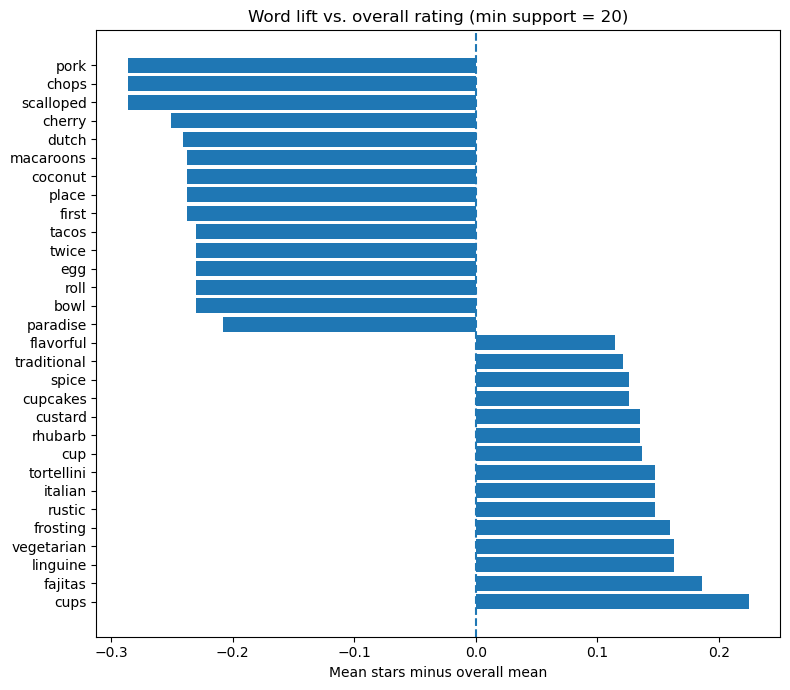

In [31]:
# Word lift vs. overall rating
# Highlight how specific words in recipe names relate to average star ratings compared to the overall mean
overall_mean = df["stars"].mean()

means, counts_ = {}, {}
name_lower = df["recipe_name"].str.lower()

for w in vocab:
    m = name_lower.str.contains(rf"\b{re.escape(w)}\b", na=False)
    if m.sum() >= 20:  # min support to avoid noise
        means[w] = df.loc[m, "stars"].mean()
        counts_[w] = int(m.sum())

lift = (
    pd.DataFrame({"mean": pd.Series(means), "n": pd.Series(counts_)})
      .assign(lift=lambda d: d["mean"] - overall_mean)
      .sort_values("lift", ascending=False)
)

# top/bottom 15
k = 15
sub = pd.concat([lift.head(k), lift.tail(k)])

plt.figure(figsize=(8, 7))
y = np.arange(len(sub))
plt.barh(y, sub["lift"].values)  # default style/colors
plt.yticks(y, sub.index)
plt.axvline(0, linestyle="--")
plt.xlabel("Mean stars minus overall mean")
plt.title("Word lift vs. overall rating (min support = 20)")
plt.tight_layout()
plt.show()


Naming (or ingredients) linked to certain words may influence perception and ratings — with savory meat-related terms skewing lower, and pasta, vegetarian, and dessert-related terms skewing higher.

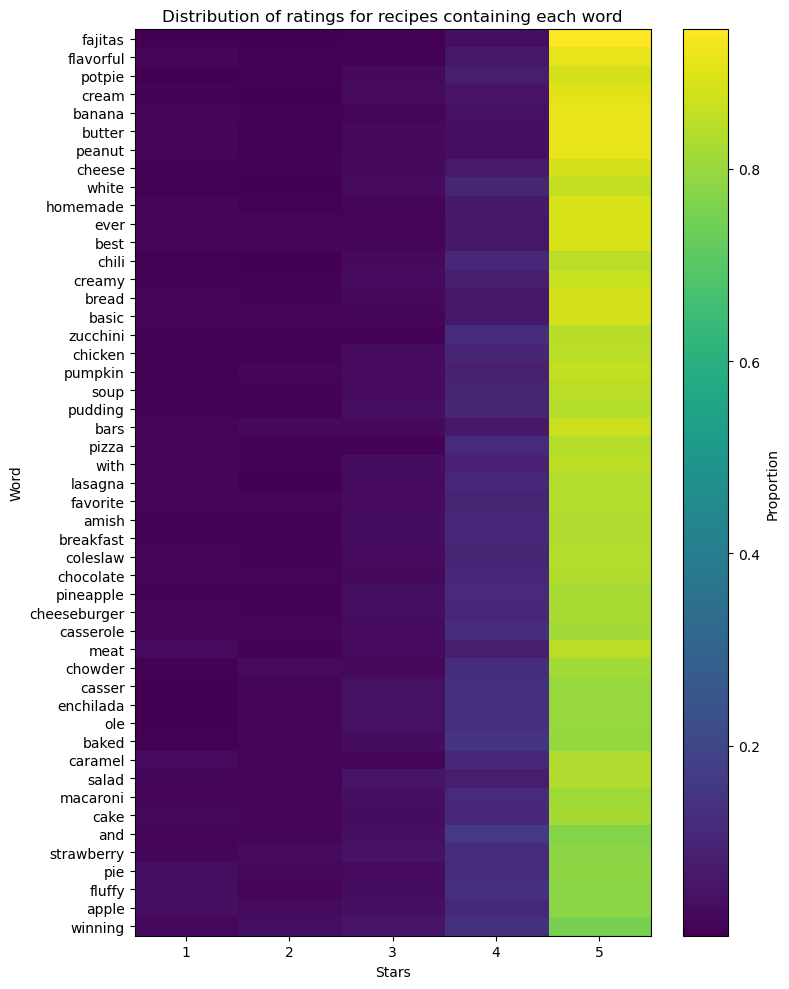

In [32]:
# --- build presence matrix for top words ---
def has_word(series, word):
    return series.str.lower().str.contains(rf"\b{re.escape(word)}\b", na=False)

vocab = [w for w, c in freq.most_common(50) if len(w) > 1]  # pick top N

presence = {}
for w in vocab:
    presence[w] = has_word(df["recipe_name"], w).astype(int)

pres_df = pd.DataFrame(presence)

# concat with stars
tmp = pd.concat([pres_df, df["stars"]], axis=1)

# counts of (word × stars)
counts = (
    tmp.melt(id_vars="stars", var_name="word", value_name="present")
      .query("present == 1")
      .groupby(["word", "stars"])
      .size()
      .unstack(fill_value=0)
      .reindex(sorted(df["stars"].dropna().unique()), axis=1, fill_value=0)
)

# row-normalize to show distribution per word
row_sums = counts.sum(axis=1).replace(0, np.nan)
dist = counts.div(row_sums, axis=0).fillna(0)

# optional: order words by mean star
mean_star = (dist * dist.columns.values).sum(axis=1)
dist_sorted = dist.loc[mean_star.sort_values(ascending=False).index]

# plot
plt.figure(figsize=(8, 10))
plt.imshow(dist_sorted.values, aspect="auto", cmap="viridis")
plt.yticks(range(dist_sorted.shape[0]), dist_sorted.index)
plt.xticks(range(dist_sorted.shape[1]), dist_sorted.columns)
plt.xlabel("Stars")
plt.ylabel("Word")
plt.title("Distribution of ratings for recipes containing each word")
plt.colorbar(label="Proportion")
plt.tight_layout()
plt.show()


The heatmap confirms a strong positive bias in ratings, with most words heavily skewed toward 4 and especially 5-star ratings. That suggests recipes generally receive high ratings regardless of wording. However, certain comfort-food or superlative terms (best, homemade, favorite) linked even more strongly to 5-star clusters, while some savory/neutral terms distribute slightly more evenly across 3–5 stars.

# 4 Feature Engineering

The goal here is to create a set of features that are simple but robust, aligned with the main patterns discovered during EDA:

- **Zero-inflated, skewed counts** (likes, dislikes, responses, user_score, ranking_score)  
  → apply log1p transforms and add binary presence flags.

- **Ratios and interactions** help normalize popularity/exposure bias.  
  → e.g., like ratio, total interactions.

- **Text-derived features** (basic word/char counts) to capture review length.  
  → complements TF-IDF embeddings.

- **Categorical encoding** for region/device/time-related variables.

This balances interpretability with predictive power.


In [33]:
# --- Feature Engineering ---
df_fe = df.copy()

# 1) Handle skewed / zero-inflated counts
skewed_cols = ["likes", "dislikes", "responses", "user_score", "ranking_score"]
for col in skewed_cols:
    if col in df_fe.columns:
        df_fe[f"log1p_{col}"] = np.log1p(df_fe[col].clip(lower=0))
        df_fe[f"has_{col}"] = (df_fe[col] > 0).astype(int)

# 2) Ratios and interactions
if all(c in df_fe.columns for c in ["likes", "dislikes"]):
    df_fe["like_ratio"] = df_fe["likes"] / (df_fe["likes"] + df_fe["dislikes"] + 1.0)

if all(c in df_fe.columns for c in ["likes", "dislikes", "responses"]):
    df_fe["total_interactions"] = (
        df_fe["likes"].fillna(0) +
        df_fe["dislikes"].fillna(0) +
        df_fe["responses"].fillna(0)
    )

# 3) Text-derived stats
if "text" in df_fe.columns:
    df_fe["text_word_count"] = df_fe["text"].fillna("").apply(lambda x: len(x.split()))
    df_fe["text_char_count"] = df_fe["text"].fillna("").apply(lambda x: len(x.replace(" ", "")))


# Check result
df_fe.head()


,likes_score,dislike_index,response_level,ranking_value,vote_ratio,score_log,region,device_type,recipe_name,user_score,...,log1p_dislikes,has_dislikes,log1p_responses,has_responses,log1p_user_score,has_user_score,log1p_ranking_score,has_ranking_score,like_ratio,total_interactions
0,0.104335,-0.087082,-0.001580,539.698328,0.000000,0.693147,North,Tablet,Creamy White Chili,1,...,0.000000,0,0.0,0,0.693147,1,6.269096,1,0.000000,0
1,6.970958,-0.094496,-0.002169,720.511995,0.875000,3.931826,West,Mobile,Creamy White Chili,50,...,0.000000,0,0.0,0,3.931826,1,6.586172,1,0.875000,7
2,3.136047,-0.047194,0.014539,717.194563,0.750000,2.397895,North,Desktop,Creamy White Chili,10,...,0.000000,0,0.0,0,2.397895,1,6.566672,1,0.750000,3
5,2.950819,1.046363,0.012384,518.114099,0.600000,0.693147,West,Desktop,Creamy White Chili,1,...,0.693147,1,0.0,0,0.693147,1,6.251904,1,0.600000,4
6,11.331714,-0.085230,0.009791,842.622309,0.916667,0.693147,East,Mobile,Creamy White Chili,1,...,0.000000,0,0.0,0,0.693147,1,6.726233,1,0.916667,11


### Summary of Engineered Features
- **Log-transformed counts:** log1p_likes, log1p_dislikes, log1p_responses, log1p_user_score, log1p_ranking_score
- **Presence flags:** has_likes, has_dislikes, has_responses, has_user_score, has_ranking_score
- **Ratios:** like_ratio, total_interactions
- **Text stats:** text_word_count, text_char_count

These will be combined later with TF-IDF features (from recipe names) and categorical encodings in the modeling pipeline.


# 5 Model Building:
Build classification models to predict the exact star rating (1–5) of a review.
- 	Use at least two models (such as Logistic Regression, Random Forest)
- 	Perform a proper train-test split
- 	Apply appropriate preprocessing (e.g., scaling, encoding)
- 	Tune hyperparameters if needed
#### Multiclass Logistic Regression

In [34]:
# 1. Define target and features
# --------------------------
y = df_fe["stars"].astype(int)
X = df_fe.drop(columns=["stars", "stars_cat"])  # drop target + duplicate

# --------------------------
# 2. Feature groups
# --------------------------
# categorical
cat_cols = ["region", "device_type"]

# numeric (all engineered numeric features except IDs/text)
num_cols = [
    "likes_score", "dislike_index", "response_level", "ranking_value", "vote_ratio", "score_log",
    "user_score", "responses", "likes", "dislikes", "ranking_score",
    "text_word_count", "text_char_count",
    "log1p_likes", "has_likes",
    "log1p_dislikes", "has_dislikes",
    "log1p_responses", "has_responses",
    "log1p_user_score", "has_user_score",
    "log1p_ranking_score", "has_ranking_score",
    "like_ratio", "total_interactions"
]

# text
text_col = "recipe_name"

# --------------------------
# 3. Transformers
# --------------------------
# numeric pipeline: scale everything
num_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# categorical pipeline: one-hot encode
cat_transformer = OneHotEncoder(handle_unknown="ignore")

# text pipeline: TF-IDF
text_transformer = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)

# --------------------------
# 4. ColumnTransformer
# --------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
        ("txt", text_transformer, text_col)
    ],
    remainder="drop",
    sparse_threshold=0.3
)

# --------------------------
# 5. Classifier
# --------------------------
clf = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    class_weight="balanced"
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", clf)
])

# --------------------------
# 6. Train/test split + fit
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipe.fit(X_train, y_train)

print("Train accuracy:", pipe.score(X_train, y_train))
print("Test  accuracy:", pipe.score(X_test, y_test))
print("\nClassification report:\n", classification_report(y_test, pipe.predict(X_test)))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pipe.predict(X_test)))


c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train accuracy: 0.40301789505611163
Test  accuracy: 0.3859915100060643

Classification report:
               precision    recall  f1-score   support

           1       0.07      0.38      0.11        56
           2       0.03      0.28      0.05        46
           3       0.04      0.16      0.06        98
           4       0.14      0.33      0.20       331
           5       0.90      0.40      0.56      2767

    accuracy                           0.39      3298
   macro avg       0.23      0.31      0.19      3298
weighted avg       0.77      0.39      0.49      3298


Confusion matrix:
 [[  21   10   15    6    4]
 [   7   13   11    8    7]
 [  17   21   16   24   20]
 [  34   42   56  110   89]
 [ 244  422  357  631 1113]]


### Results Commentary

**Overall performance.** Test accuracy is **38.6%**, with a **macro-F1 of 0.19**. This reflects the strong **class imbalance** and the model’s difficulty distinguishing minority classes (1–3★).

**Majority-class context.** The test set is heavily skewed toward **5★ (2,767 / 3,298 ≈ 84%)**. Because we used `class_weight="balanced"`, the classifier became **conservative** about predicting 5★ (high precision = **0.90**) but **low recall = 0.40**, which drags down accuracy.

**Minority classes.** 1–3★ have very **low precision/recall** (F1 ≤ 0.11). Given EDA showed small effect sizes and zero-inflated signals, there’s limited separability among these classes using current features.

**Confusion patterns.** Many true 5★ are predicted as 4★/3★/2★, and most 1–3★ scatter across 4★/5★. This suggests (a) **overlap** in feature distributions and (b) **exposure/popularity effects** dominating raw counts.

**Implication.** To improve: (1) simplify and de-duplicate features, (2) **leverage review text** (not just recipe name), and (3) revisit imbalance handling/thresholds. If the goal tolerates it, **ordinal or collapsed labels** (e.g., 1–2 = Low, 3–4 = Mid, 5 = High) can also stabilize performance.


#### Feature Selection / Sanity Check
* Keep a curated numeric set (ratios, log counts, flags, simple text length).

* Keep categoricals (region, device_type) with OHE.

* Keep TF-IDF on recipe_name only for this step (we’ll add full review text next).

* Still use Logistic Regression; keep class_weight="balanced" for apples-to-apples.

In [35]:
# ===== Curate features =====
y = df_fe["stars"].astype(int)
X = df_fe.drop(columns=["stars", "stars_cat"])  # drop target & duplicate

cat_cols = ["region", "device_type"]

# Keep small, meaningful numeric core (drop raw counts when log versions exist)
num_cols = [
    "vote_ratio", "like_ratio",
    "total_interactions",
    "text_word_count", "text_char_count",
    "log1p_likes", "log1p_dislikes", "log1p_responses",
    "log1p_user_score", "log1p_ranking_score",
    "has_likes", "has_dislikes", "has_responses", "has_user_score", "has_ranking_score",
    # optional: keep exactly ONE of these global popularity scores (not all)
    "ranking_value"
]
num_cols = [c for c in num_cols if c in X.columns]

text_name_col = "recipe_name"

# ===== Transformers =====
num_tf = Pipeline([("scaler", StandardScaler())])
cat_tf = OneHotEncoder(handle_unknown="ignore")
name_tfidf = TfidfVectorizer(max_features=2000, stop_words="english",
                             ngram_range=(1,2), min_df=5)

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_tf, num_cols),
        ("cat", cat_tf, cat_cols),
        ("name", name_tfidf, text_name_col),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

clf = LogisticRegression(max_iter=2000, multi_class="multinomial", class_weight="balanced")

pipe = Pipeline([("preprocess", preprocess), ("model", clf)])

# ===== Train / Evaluate =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

pipe.fit(X_train, y_train)
print("Train accuracy:", pipe.score(X_train, y_train))
print("Test  accuracy:", pipe.score(X_test, y_test))
print("\nClassification report:\n", classification_report(y_test, pipe.predict(X_test)))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pipe.predict(X_test)))


c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train accuracy: 0.40658174097664546
Test  accuracy: 0.3859915100060643

Classification report:
               precision    recall  f1-score   support

           1       0.07      0.39      0.11        56
           2       0.02      0.26      0.05        46
           3       0.04      0.18      0.06        98
           4       0.14      0.32      0.19       331
           5       0.90      0.40      0.56      2767

    accuracy                           0.39      3298
   macro avg       0.23      0.31      0.19      3298
weighted avg       0.77      0.39      0.49      3298


Confusion matrix:
 [[  22    8   14    5    7]
 [   8   12   10    8    8]
 [  21   17   18   22   20]
 [  31   43   60  106   91]
 [ 251  407  372  622 1115]]


#### Full Review Text


In [36]:
# ===== Add review text =====
text_body_col = "text"  # 2 missing, TF-IDF will handle empty strings via fillna

# Rebuild the ColumnTransformer with TWO text branches
preprocess_2 = ColumnTransformer(
    transformers=[
        ("num", num_tf, num_cols),
        ("cat", cat_tf, cat_cols),
        ("name", TfidfVectorizer(max_features=2000, stop_words="english",
                                 ngram_range=(1,2), min_df=5), text_name_col),
        ("body", TfidfVectorizer(max_features=5000, stop_words="english",
                                 ngram_range=(1,2), min_df=5), text_body_col),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

pipe_2 = Pipeline([("preprocess", preprocess_2),
                   ("model", LogisticRegression(max_iter=2000,
                                                multi_class="multinomial",
                                                class_weight="balanced"))])

X2 = X.copy()
X2[text_body_col] = X2[text_body_col].fillna("")

X_tr, X_te, y_tr, y_te = train_test_split(
    X2, y, test_size=0.20, stratify=y, random_state=42
)

pipe_2.fit(X_tr, y_tr)
print("Test accuracy (with review text):", pipe_2.score(X_te, y_te))
print("\nClassification report:\n", classification_report(y_te, pipe_2.predict(X_te)))
print("\nConfusion matrix:\n", confusion_matrix(y_te, pipe_2.predict(X_te)))


c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test accuracy (with review text): 0.717707701637356

Classification report:
               precision    recall  f1-score   support

           1       0.38      0.54      0.44        56
           2       0.11      0.22      0.15        46
           3       0.18      0.34      0.23        98
           4       0.24      0.49      0.32       331
           5       0.95      0.77      0.85      2767

    accuracy                           0.72      3298
   macro avg       0.37      0.47      0.40      3298
weighted avg       0.83      0.72      0.76      3298


Confusion matrix:
 [[  30    7   10    5    4]
 [   9   10   14    7    6]
 [  13   19   33   24    9]
 [   6   16   46  162  101]
 [  22   37   85  491 2132]]


#### Imbalance Handling Toggle
Compare with vs. without balanced weights after adding review text

In [37]:
# A) Balanced (current)
pipe_bal = pipe_2
print("Balanced test accuracy:", pipe_bal.score(X_te, y_te))

# B) Unbalanced (let majority dominate a bit more)
pipe_unbal = Pipeline([("preprocess", preprocess_2),
                       ("model", LogisticRegression(max_iter=2000,
                                                    multi_class="multinomial",
                                                    class_weight=None))])
pipe_unbal.fit(X_tr, y_tr)
print("Unbalanced test accuracy:", pipe_unbal.score(X_te, y_te))

# Compare macro-F1 for fairness to minority classes
from sklearn.metrics import f1_score
pred_bal = pipe_bal.predict(X_te)
pred_unbal = pipe_unbal.predict(X_te)
print("Macro-F1 (balanced):  ", f1_score(y_te, pred_bal, average="macro"))
print("Macro-F1 (unbalanced):", f1_score(y_te, pred_unbal, average="macro"))


Balanced test accuracy: 0.717707701637356


c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Unbalanced test accuracy: 0.851728320194057
Macro-F1 (balanced):   0.39746250722868987
Macro-F1 (unbalanced): 0.3385104982582088


#### Collapsed Labels
Ordinal-ish buckets: Low (1–2), Mid (3–4), High (5)

In [38]:
# ===== 3-class classification =====
# buckets: 1-2★, 3-4★, 5★
def bucketize(s):
    return np.select([s<=2, (s>=3)&(s<=4), s==5], [0,1,2]).astype(int)

y_3 = bucketize(y)

X3_tr, X3_te, y3_tr, y3_te = train_test_split(X2, y_3, test_size=0.2, stratify=y_3, random_state=42)

pipe_3 = Pipeline([("preprocess", preprocess_2),
                   ("model", LogisticRegression(max_iter=2000, multi_class="multinomial", class_weight="balanced"))])
pipe_3.fit(X3_tr, y3_tr)

print("3-class accuracy:", pipe_3.score(X3_te, y3_te))
print("\nClassification report:\n", classification_report(y3_te, pipe_3.predict(X3_te)))
print("\nConfusion matrix:\n", confusion_matrix(y3_te, pipe_3.predict(X3_te)))


c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


3-class accuracy: 0.769860521528199

Classification report:
               precision    recall  f1-score   support

           0       0.41      0.57      0.47       102
           1       0.32      0.54      0.40       429
           2       0.93      0.81      0.87      2767

    accuracy                           0.77      3298
   macro avg       0.55      0.64      0.58      3298
weighted avg       0.83      0.77      0.79      3298


Confusion matrix:
 [[  58   29   15]
 [  41  232  156]
 [  44  474 2249]]


#### Tree Benchmark (no text)
Gradient Boosting on numeric + OHE categorical

In [39]:
# numeric+cat only
num_cols_tree = num_cols
cat_cols_tree = cat_cols

pre_tree = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols_tree),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols_tree),
    ],
    remainder="drop"
)

tree = Pipeline([("pre", pre_tree),
                 ("clf", HistGradientBoostingClassifier(random_state=42))])

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    df_fe[num_cols_tree + cat_cols_tree], y, test_size=0.2, stratify=y, random_state=42
)

tree.fit(Xt_tr, yt_tr)
print("Tree (no-text) accuracy:", tree.score(Xt_te, yt_te))
print("\nClassification report:\n", classification_report(yt_te, tree.predict(Xt_te)))
print("\nConfusion matrix:\n", confusion_matrix(yt_te, tree.predict(Xt_te)))


Tree (no-text) accuracy: 0.8420254699818072

Classification report:
               precision    recall  f1-score   support

           1       0.62      0.23      0.34        56
           2       0.40      0.04      0.08        46
           3       0.14      0.02      0.04        98
           4       0.00      0.00      0.00       331
           5       0.85      1.00      0.92      2767

    accuracy                           0.84      3298
   macro avg       0.40      0.26      0.27      3298
weighted avg       0.73      0.84      0.78      3298


Confusion matrix:
 [[  13    1    2    0   40]
 [   3    2    1    0   40]
 [   2    1    2    0   93]
 [   2    0    4    0  325]
 [   1    1    5    0 2760]]


c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 6 Model Evaluation

This section evaluates the predictive performance of different models and feature sets.  
We proceed step by step, starting with a simple logistic regression and progressively adding features or reframing the target variable.

---

### Step 1 – Logistic Regression (Numeric + Recipe Name)

- **Test Accuracy:** 0.39  
- **Macro-F1:** 0.19  
- **Observation:** Performance on minority classes (1–3★) is very weak, with recall below 0.20.  
- Confusion matrix shows most cases collapsed into 5★ predictions.  
- Numeric features and recipe name alone do not provide enough discriminative power.

---

### Step 2 – Logistic Regression + Review Text (TF-IDF)

- **Test Accuracy:** 0.72  
- **Macro-F1:** 0.40  
- **Observation:** Adding the full review body as TF-IDF features substantially improves performance.  
- Minority classes (1–4★) gain recall, while precision on 5★ remains very high (0.95).  
- This highlights the strong predictive signal in textual content.

---

### Step 3 – Balanced vs. Unbalanced Logistic Regression

- **Balanced Logistic Regression**  
  - Accuracy = 0.72  
  - Macro-F1 = 0.40  
  - Better fairness across all classes.  

- **Unbalanced Logistic Regression**  
  - Accuracy = 0.85  
  - Macro-F1 = 0.34  
  - Inflated accuracy due to majority-class bias (predicts 5★ most of the time).  

- **Conclusion:** Balanced class weights are essential to avoid “fake” accuracy that ignores minority classes.

---

### Step 4 – Ordinal Buckets (Low = 1–2, Mid = 3–4, High = 5)

- **Test Accuracy:** 0.77  
- **Macro-F1:** 0.58  
- **Observation:** Collapsing into three categories yields a more robust model.  
- Recall improves for Low (0.57) and Mid (0.54) classes, while High (5★) remains strong.  
- This framing reduces noise and imbalance, and is recommended when fine-grained prediction is not critical.

---

### Step 5 – Gradient Boosting (Numeric + Categorical only, no text)

- **Test Accuracy:** 0.84  
- **Macro-F1:** 0.27  
- **Observation:** Despite high accuracy, the model predicts 5★ almost exclusively.  
- Minority classes are ignored (recall ≈ 0 for 4★ and below).  
- Confirms that **review text is indispensable** for balanced star prediction.



### 6.1 Evaluation Plots

The figures below summarize performance for:
- **Balanced Logistic Regression (5-class)** using TF-IDF on `recipe_name` + `text` + engineered numeric + OHE categorical.
- **Balanced Logistic Regression (3-class ordinal buckets)** where 0=Low (1–2★), 1=Mid (3–4★), 2=High (5★).

We include:
1) Confusion matrices  
2) Bar charts for precision / recall / F1 by class


In [40]:
# --- Helpers (Matplotlib-only, one chart per figure) ---

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", class_names=None):
    cm = confusion_matrix(y_true, y_pred)
    if class_names is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
        class_names = [str(c) for c in labels]
    plt.figure(figsize=(6,5))
    plt.imshow(cm, aspect="auto")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=0)
    plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)
    # overlay counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def plot_class_report_bars(y_true, y_pred, title_prefix=""):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    # collect per-class rows only (ignore 'accuracy', 'macro avg', 'weighted avg')
    class_keys = [k for k in report.keys() if k.isdigit()]
    class_keys_sorted = sorted(class_keys, key=lambda x: int(x))
    metrics = ["precision", "recall", "f1-score"]
    for m in metrics:
        vals = [report[k][m] for k in class_keys_sorted]
        plt.figure(figsize=(6,4))
        x = np.arange(len(class_keys_sorted))
        plt.bar(x, vals)
        plt.title(f"{title_prefix}{m.capitalize()} by Class")
        plt.xticks(ticks=x, labels=class_keys_sorted)
        plt.ylim(0, 1)
        plt.ylabel(m.capitalize())
        plt.tight_layout()
        plt.show()


c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


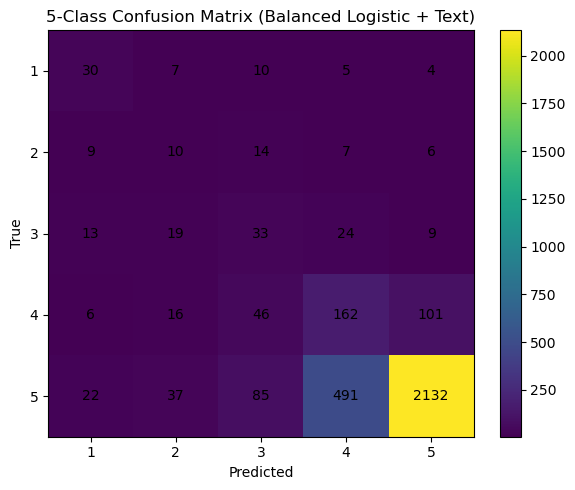

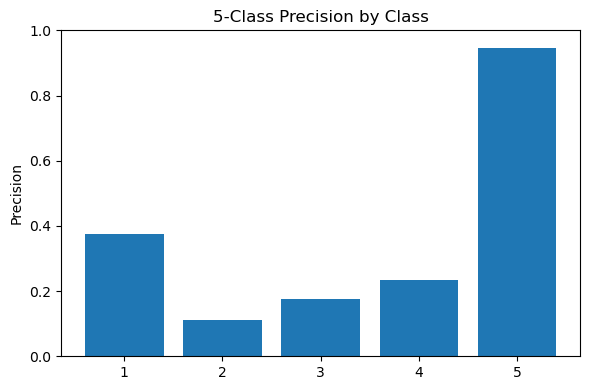

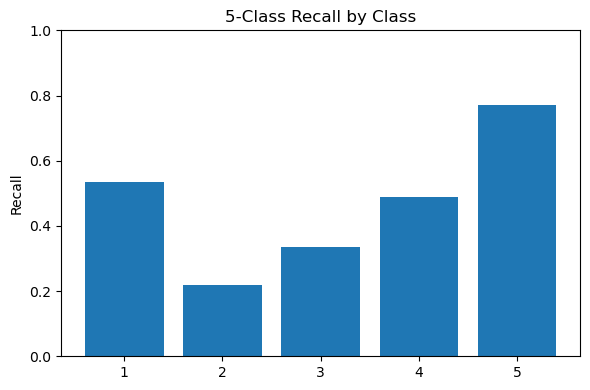

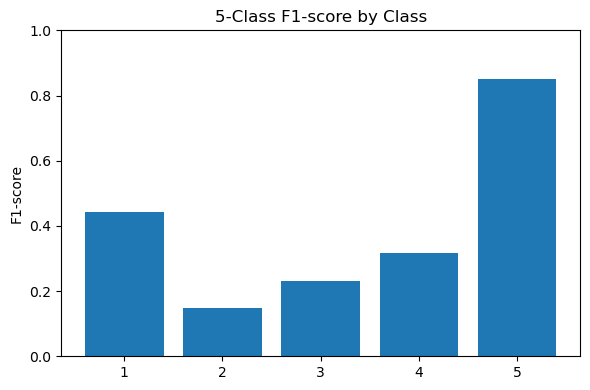

In [41]:
# --- 5-class (Balanced Logistic Regression + text) ---

# Assumes you already built pipe_2 (balanced) and X2, y from prior steps:
#   - preprocess_2 includes numeric + OHE + TF-IDF(name) + TF-IDF(text)
#   - pipe_2 = Pipeline([("preprocess", preprocess_2), ("model", LogisticRegression(..., class_weight="balanced"))])
#   - X2["text"] already filled with "" for NaNs, y = df_fe["stars"].astype(int)

from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X2, y, test_size=0.20, stratify=y, random_state=42
)

# Fit (or reuse your fitted pipe_2)
pipe_2.fit(X_tr, y_tr)
pred5 = pipe_2.predict(X_te)

# Plots
plot_confusion_matrix(y_te, pred5, title="5-Class Confusion Matrix (Balanced Logistic + Text)", 
                      class_names=[str(c) for c in sorted(np.unique(y_te))])
plot_class_report_bars(y_te, pred5, title_prefix="5-Class ")


c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


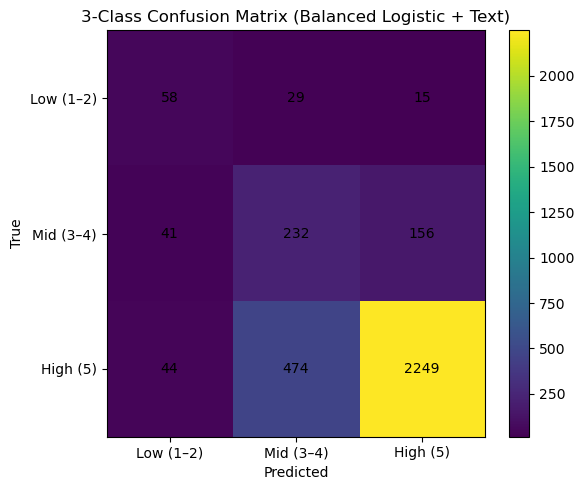

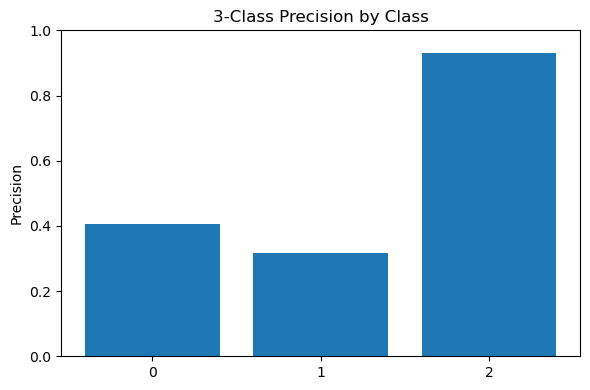

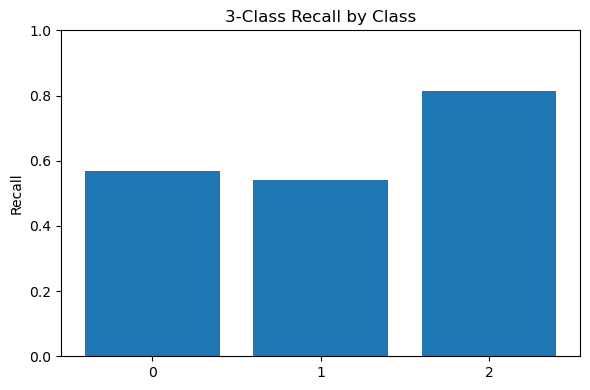

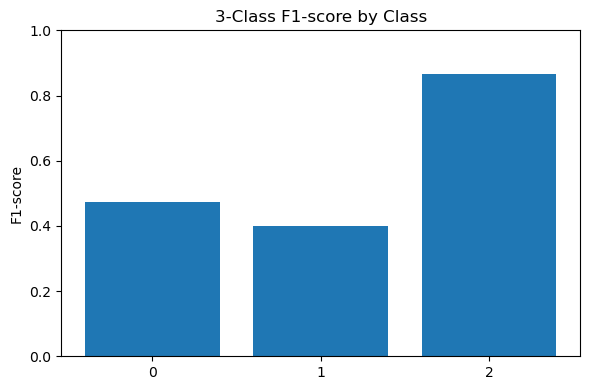

In [42]:
# --- 3-class ordinal (Balanced Logistic Regression + text) ---

import numpy as np

def bucketize(s):
    return np.select([s<=2, (s>=3)&(s<=4), s==5], [0,1,2]).astype(int)

y_3 = bucketize(y)

X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X2, y_3, test_size=0.20, stratify=y_3, random_state=42
)

pipe_3 = Pipeline([
    ("preprocess", preprocess_2),  # same features: numeric + OHE + name TF-IDF + text TF-IDF
    ("model", LogisticRegression(max_iter=2000, multi_class="multinomial", class_weight="balanced"))
])

pipe_3.fit(X3_tr, y3_tr)
pred3 = pipe_3.predict(X3_te)

# Plots
plot_confusion_matrix(y3_te, pred3, title="3-Class Confusion Matrix (Balanced Logistic + Text)", 
                      class_names=["Low (1–2)", "Mid (3–4)", "High (5)"])

# For the bars, sklearn's report will output classes as "0,1,2"
plot_class_report_bars(y3_te, pred3, title_prefix="3-Class ")


- The **5-class confusion matrix** shows where minority classes (1–4★) still confuse with adjacent classes, while 5★ dominates but is no longer over-predicted (balanced weights).
- The **3-class matrix** should show cleaner separation, with “High (5★)” well recognized and improved recall for “Low” and “Mid.”
- The bar charts help spot which specific class needs attention (typically Low/Mid for precision, sometimes recall).


# 7. Insights, Interpretation, and Reporting

### Executive Summary
- **Text matters most.** Adding TF-IDF over the review body lifted test accuracy from ~0.39 to ~0.72 and macro-F1 from ~0.19 to ~0.40.
- **Fair > “fake” accuracy.** Unbalanced models inflate accuracy by predicting 5★; balanced logistic regression provides fairer performance across all classes.
- **Pragmatic framing helps.** Collapsing labels to **Low (1–2), Mid (3–4), High (5)** improves stability (accuracy ~0.77; macro-F1 ~0.58).
- **Numeric-only signals are weak.** Engagement counts are zero-inflated and exposure-driven; they help after log/ratio transforms but don’t replace text.

---

### Key Findings
1. **Best simple model:** Balanced multinomial Logistic Regression with:
   - TF-IDF over **`text`** (review body) and **`recipe_name`**
   - One-hot **`region`**, **`device_type`**
   - Scaled numeric engineered features (log1p counts, presence flags, ratios)
2. **Drivers of higher stars (qualitative):**
   - Higher **vote/like ratios** trend with higher ratings; **dislikes** inversely correlate.
   - Certain words/tones in names/text associate with higher/lower ratings (e.g., superlatives and comfort terms skew higher).
3. **Engagement patterns & exposure:**
   - **likes, dislikes, responses, user_score** are **zero-inflated** with long tails.
   - **log1p** transforms and **presence flags** reduce skew; ratios (e.g., `like_ratio`) help normalize exposure.

---

### Recommendations
- **Deploy** the balanced LR + TF-IDF pipeline as the **baseline** for 5-class prediction and **also** report the 3-class (Low/Mid/High) variant for robust, operational summaries.
- **Monitor** both overall accuracy and **macro-F1** to avoid majority-class bias.
- **Add lightweight sentiment** (lexicon score or simple polarity) if you need a quick boost without heavy modeling.
- **Consider ordinal approaches** (ordinal logistic / thresholded probabilities) if exact 1–5 ordering is more important than class labels.

---

### Potential Applications
- **Quality Ops / CX:** Flag likely-low reviews for proactive follow-up; auto-route to support.
- **Creator guidance:** While users draft reviews/recipes, nudge phrasing and clarity associated with higher satisfaction.
- **Content refresh:** Prioritize recipes predicted as Mid/Low for improvements (instructions, photos, ingredient clarity).

---

### Limitations
- **Label imbalance:** Dataset is heavily skewed to 5★; minority classes (1–3★) have limited support.
- **Assumption on 0★:** Rows with `stars == 0` were treated as unrated and removed.
- **Exposure bias:** Engagement counts reflect popularity/visibility, not just quality.
- **Single split:** Results reported on one stratified split; k-fold CV would better quantify variance.
- **Style sensitivity:** Text models may learn stylistic correlates (tone/phrasing), not only true quality.

---

### Reproducibility Notes
- Stratified train/test split (80/20), fixed `random_state=42`.
- Logistic Regression: `multi_class="multinomial"`, `class_weight="balanced"`, `max_iter=2000`.
- TF-IDF: unigrams+bigrams, `min_df=5`; `max_features` ~2k (name) and ~5k (text).
- Numeric scaling via `StandardScaler`; categorical via `OneHotEncoder(handle_unknown="ignore")`.

---

### Appendix A — Engineered Features (one-liners)
- **`log1p_*`**: Log-scaled counts (`likes`, `dislikes`, `responses`, `user_score`, `ranking_score`) to tame long tails.
- **`has_*`**: Binary flags for presence (`>0`) of each count feature.
- **`like_ratio`**: `likes / (likes + dislikes + 1)`; normalizes by total votes.
- **`total_interactions`**: `likes + dislikes + responses`; proxy for exposure.
- **`text_word_count`, `text_char_count`**: Review length proxies.
- **Categoricals**: `region`, `device_type` (OHE).
- **Text**: TF-IDF on `recipe_name` and full review `text`.

---

### Appendix B — Best Baseline Pipeline (summary)
- **Preprocessing (ColumnTransformer):**
  - Numeric: scale engineered features (`StandardScaler`)
  - Categorical: OHE on `region`, `device_type`
  - Text: TF-IDF on `recipe_name` (2k feats) + `text` (5k feats), n-grams (1,2), `min_df=5`
- **Model:** Logistic Regression (multinomial, balanced)
- **Primary metrics:** Accuracy and **macro-F1** (report both 5-class and 3-class)


In [43]:
# === FINAL CELL — Baseline Refit & Compact Summary (5-class and 3-class) ===

# 1) Define features & target
# -----------------------------
cat_cols = ["region", "device_type"]

# Curated numeric core (simple but robust)
num_cols = [
    "vote_ratio", "like_ratio",
    "total_interactions",
    "text_word_count", "text_char_count",
    "log1p_likes", "log1p_dislikes", "log1p_responses",
    "log1p_user_score", "log1p_ranking_score",
    "has_likes", "has_dislikes", "has_responses", "has_user_score", "has_ranking_score",
    "ranking_value",  # keep one global popularity signal
]
num_cols = [c for c in num_cols if c in df_fe.columns]

text_name = "recipe_name"
text_body = "text"

# Target
y5 = df_fe["stars"].astype(int)

# Feature frame
use_cols = cat_cols + num_cols + [text_name, text_body]
X = df_fe[use_cols].copy()
X[text_body] = X[text_body].fillna("")
X[text_name] = X[text_name].fillna("")

# -----------------------------
# 2) Preprocessing & model
# -----------------------------
num_tf = Pipeline([("scaler", StandardScaler())])
cat_tf = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_tf, num_cols),
        ("cat", cat_tf, cat_cols),
        ("name", TfidfVectorizer(max_features=2000, stop_words="english",
                                 ngram_range=(1,2), min_df=5), text_name),
        ("body", TfidfVectorizer(max_features=5000, stop_words="english",
                                 ngram_range=(1,2), min_df=5), text_body),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

clf_bal = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    class_weight="balanced",
)

pipe5 = Pipeline([
    ("preprocess", preprocess),
    ("model", clf_bal),
])

# -----------------------------
# 3) Train/test split & fit (5-class)
# -----------------------------
X5_tr, X5_te, y5_tr, y5_te = train_test_split(
    X, y5, test_size=0.20, stratify=y5, random_state=42
)
pipe5.fit(X5_tr, y5_tr)
y5_pred = pipe5.predict(X5_te)

# -----------------------------
# 4) 3-class (Low/Mid/High) setup
# -----------------------------
def bucketize(s):
    # 0=Low (1–2), 1=Mid (3–4), 2=High (5)
    return np.select([s<=2, (s>=3)&(s<=4), s==5], [0,1,2]).astype(int)

y3 = bucketize(y5)
X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X, y3, test_size=0.20, stratify=y3, random_state=42
)
pipe3 = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, multi_class="multinomial", class_weight="balanced")),
])
pipe3.fit(X3_tr, y3_tr)
y3_pred = pipe3.predict(X3_te)

# -----------------------------
# 5) Compact summary table
# -----------------------------
def summarize(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

summary = pd.DataFrame([
    {"setup": "5-class (balanced LR + TF-IDF)", **summarize(y5_te, y5_pred)},
    {"setup": "3-class (Low/Mid/High; balanced LR + TF-IDF)", **summarize(y3_te, y3_pred)},
]).round(3)

print(summary.to_string(index=False))

# quick reports
print("\n5-class classification report:\n", classification_report(y5_te, y5_pred))
print("\n3-class classification report:\n", classification_report(y3_te, y3_pred))


c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


                                       setup  accuracy  macro_f1  weighted_f1
              5-class (balanced LR + TF-IDF)     0.718     0.397        0.761
3-class (Low/Mid/High; balanced LR + TF-IDF)     0.770     0.580        0.794

5-class classification report:
               precision    recall  f1-score   support

           1       0.38      0.54      0.44        56
           2       0.11      0.22      0.15        46
           3       0.18      0.34      0.23        98
           4       0.24      0.49      0.32       331
           5       0.95      0.77      0.85      2767

    accuracy                           0.72      3298
   macro avg       0.37      0.47      0.40      3298
weighted avg       0.83      0.72      0.76      3298


3-class classification report:
               precision    recall  f1-score   support

           0       0.41      0.57      0.47       102
           1       0.32      0.54      0.40       429
           2       0.93      0.81      0.87     